In [1]:
pip install datasets

In [ ]:
# Importing required libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import scipy.io
import requests
from pathlib import Path
import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# import matplotlib.colors as mcolors
from matplotlib.patches import FancyBboxPatch
# from pathlib import Path


class IndianPinesVisualizer:

    CLASS_NAMES = {
        0: "Background",
        1: "Alfalfa",
        2: "Corn-notill",
        3: "Corn-mintill",
        4: "Corn",
        5: "Grass-pasture",
        6: "Grass-trees",
        7: "Grass-pasture-mowed",
        8: "Hay-windrowed",
        9: "Oats",
        10: "Soybean-notill",
        11: "Soybean-mintill",
        12: "Soybean-clean",
        13: "Wheat",
        14: "Woods",
        15: "Buildings-Grass-Trees-Drives",
        16: "Stone-Steel-Towers",
    }

    def __init__(self):
        self.data = None
        self.labels = None
        self.wavelengths = None

    # ------------------------------------------------------------------
    # Data loading
    # ------------------------------------------------------------------

    def download_file(self, url, file_path):
        """
        Download one file and verify that the server did not return HTML.
        """
        print(f"Downloading {file_path.name}...")

        response = requests.get(
            url,
            timeout=120,
            allow_redirects=True,
        )
        response.raise_for_status()

        content = response.content
        content_type = response.headers.get("Content-Type", "").lower()
        beginning = content[:500].lower()

        if (
            "text/html" in content_type
            or b"<!doctype html" in beginning
            or b"<html" in beginning
        ):
            raise RuntimeError(
                f"Received HTML instead of a MAT file from:\n{response.url}"
            )

        if len(content) < 128:
            raise RuntimeError(
                f"{file_path.name} is suspiciously small: "
                f"{len(content)} bytes"
            )

        file_path.write_bytes(content)

        print(
            f"Downloaded {file_path.name} "
            f"({len(content) / 1024:.1f} KB)"
        )

    def download_dataset(self, force_download=False):
        """
        Download the Indian Pines dataset.
        """
        data_directory = Path("data")
        data_directory.mkdir(exist_ok=True)

        data_url = (
            "https://huggingface.co/datasets/danaroth/indian_pines/"
            "resolve/main/Indian_pines_corrected.mat"
        )

        labels_url = (
            "https://huggingface.co/datasets/danaroth/indian_pines/"
            "resolve/main/Indian_pines_gt.mat"
        )

        data_path = data_directory / "Indian_pines_corrected.mat"
        labels_path = data_directory / "Indian_pines_gt.mat"

        files = [
            (data_url, data_path),
            (labels_url, labels_path),
        ]

        for url, file_path in files:
            if force_download or not file_path.exists():
                self.download_file(url, file_path)
            else:
                print(f"Using existing file: {file_path}")

        return data_path, labels_path

    def load_data(self):
        """
        Download and load the Indian Pines dataset.
        """
        data_path, labels_path = self.download_dataset()

        try:
            data_mat = scipy.io.loadmat(data_path)
            labels_mat = scipy.io.loadmat(labels_path)

        except (ValueError, OSError):
            print("Existing files appear invalid. Downloading fresh copies...")

            data_path, labels_path = self.download_dataset(
                force_download=True
            )

            data_mat = scipy.io.loadmat(data_path)
            labels_mat = scipy.io.loadmat(labels_path)

        self.data = data_mat["indian_pines_corrected"]
        self.labels = labels_mat["indian_pines_gt"]

        # Approximate wavelength scale only.
        self.wavelengths = np.linspace(
            400,
            2500,
            self.data.shape[2],
        )

        print(f"Data shape: {self.data.shape}")
        print(f"Labels shape: {self.labels.shape}")

    # ------------------------------------------------------------------
    # Paper plotting style
    # ------------------------------------------------------------------


    # ----------------------------------------------------------------------
    # Replace the plotting/helper portion of IndianPinesVisualizer with this.
    # Keep your existing CLASS_NAMES, download_dataset(), load_data(), etc.
    # ----------------------------------------------------------------------

    def _set_paper_style(self):
        """
        Large typography intended to remain readable after figures are
        scaled down in a two-column paper.
        """
        plt.rcParams.update({
            "font.family": "serif",

            # Intentionally larger than normal figure text.
            "font.size": 11,
            "axes.titlesize": 12,
            "axes.labelsize": 11,
            "xtick.labelsize": 9.5,
            "ytick.labelsize": 9.5,
            "legend.fontsize": 9,

            "axes.linewidth": 0.8,
            "lines.linewidth": 1.8,

            "figure.dpi": 150,
            "savefig.dpi": 600,

            # Embed editable TrueType fonts in PDF.
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        })


    def _robust_normalize(
        self,
        image,
        lower_percentile=2,
        upper_percentile=98,
    ):
        """
        Robustly normalize an array to [0, 1].
        """
        image = image.astype(np.float64)

        low = np.percentile(image, lower_percentile)
        high = np.percentile(image, upper_percentile)

        if high <= low:
            return np.zeros_like(image, dtype=np.float64)

        return np.clip(
            (image - low) / (high - low),
            0,
            1,
        )


    def _false_color_from_cube(
        self,
        cube,
        bands=(30, 20, 10),
    ):
        """
        Produce an RGB visualization from any H x W x B HSI cube.

        Each RGB channel is independently percentile-normalized.
        """
        rgb = np.zeros(
            (cube.shape[0], cube.shape[1], 3),
            dtype=np.float64,
        )

        for channel, band in enumerate(bands):
            if band >= cube.shape[2]:
                raise ValueError(
                    f"Band {band} is outside cube with "
                    f"{cube.shape[2]} bands."
                )

            rgb[:, :, channel] = self._robust_normalize(
                cube[:, :, band]
            )

        return rgb


    def create_false_color(
        self,
        bands=(30, 20, 10),
    ):
        """
        Create a publication-friendly false-color image.
        """
        if self.data is None:
            raise ValueError("No data loaded")

        return self._false_color_from_cube(
            self.data,
            bands=bands,
        )


    # ======================================================================
    # PATCH EXTRACTION
    # ======================================================================

    def _extract_spatial_patch(
        self,
        patch_size=64,
        center=None,
    ):
        """
        Extract a square HSI patch.

        If center is None, the center of the labeled region is used.
        """
        if self.data is None or self.labels is None:
            raise ValueError("No data loaded")

        height, width, _ = self.data.shape

        if patch_size > min(height, width):
            raise ValueError(
                "patch_size is larger than the spatial dimensions."
            )

        if center is None:
            rows, cols = np.where(self.labels > 0)

            if len(rows) > 0:
                center_row = int(
                    round((rows.min() + rows.max()) / 2)
                )
                center_col = int(
                    round((cols.min() + cols.max()) / 2)
                )
            else:
                center_row = height // 2
                center_col = width // 2

        else:
            center_row, center_col = center

        half = patch_size // 2

        row_start = center_row - half
        col_start = center_col - half

        row_start = max(
            0,
            min(row_start, height - patch_size),
        )

        col_start = max(
            0,
            min(col_start, width - patch_size),
        )

        row_end = row_start + patch_size
        col_end = col_start + patch_size

        cube = self.data[
            row_start:row_end,
            col_start:col_end,
            :
        ]

        labels = self.labels[
            row_start:row_end,
            col_start:col_end,
        ]

        coordinates = {
            "row_start": row_start,
            "row_end": row_end,
            "col_start": col_start,
            "col_end": col_end,
        }

        return cube, labels, coordinates


    # ======================================================================
    # SPATIAL MASK
    # ======================================================================

    def _make_block_mask(
        self,
        height,
        width,
        block_size=8,
        mask_ratio=0.50,
        seed=7,
    ):
        """
        Generate a block-wise spatial mask.

        True = masked.

        This is more representative of an MAE token mask than masking
        isolated individual image pixels.
        """
        rng = np.random.default_rng(seed)

        grid_rows = int(np.ceil(height / block_size))
        grid_cols = int(np.ceil(width / block_size))

        total_blocks = grid_rows * grid_cols

        number_masked = int(
            round(total_blocks * mask_ratio)
        )

        indices = rng.choice(
            total_blocks,
            size=number_masked,
            replace=False,
        )

        mask = np.zeros(
            (height, width),
            dtype=bool,
        )

        for index in indices:

            grid_row = index // grid_cols
            grid_col = index % grid_cols

            row_start = grid_row * block_size
            row_end = min(
                row_start + block_size,
                height,
            )

            col_start = grid_col * block_size
            col_end = min(
                col_start + block_size,
                width,
            )

            mask[
                row_start:row_end,
                col_start:col_end
            ] = True

        return mask


    def _apply_gray_mask(
        self,
        rgb,
        mask,
        gray_value=0.55,
    ):
        """
        Gray masked spatial locations in an RGB visualization.
        """
        result = rgb.copy()

        result[mask] = np.array(
            [gray_value, gray_value, gray_value]
        )

        return result


    # ======================================================================
    # FIGURE 1: FALSE COLOR + GROUND TRUTH
    # ======================================================================

    def plot_scene_and_ground_truth(
        self,
        bands=(30, 20, 10),
        save=True,
        output_dir="figures",
    ):
        """
        False-color Indian Pines scene and categorical ground truth.

        Intended for figure* / two-column width.
        """
        if self.data is None or self.labels is None:
            raise ValueError("No data loaded")

        self._set_paper_style()

        output_dir = Path(output_dir)
        output_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        false_color = self.create_false_color(
            bands=bands
        )

        tab20 = plt.get_cmap("tab20")

        colors = [
            "#000000",
            *[tab20(i) for i in range(16)],
        ]

        cmap = mcolors.ListedColormap(colors)

        boundaries = np.arange(
            -0.5,
            17.5,
            1,
        )

        norm = mcolors.BoundaryNorm(
            boundaries,
            cmap.N,
        )

        # A little taller than before so the larger legend remains readable.
        fig, axes = plt.subplots(
            1,
            2,
            figsize=(7.15, 3.45),
            gridspec_kw={
                "wspace": 0.06,
            },
        )

        # False color
        axes[0].imshow(
            false_color,
            interpolation="nearest",
        )

        axes[0].set_title(
            "(a) False-color composite",
            fontsize=12,
            pad=5,
        )

        axes[0].axis("off")

        # Ground truth
        axes[1].imshow(
            self.labels,
            cmap=cmap,
            norm=norm,
            interpolation="nearest",
        )

        axes[1].set_title(
            "(b) Ground truth",
            fontsize=12,
            pad=5,
        )

        axes[1].axis("off")

        legend_handles = []

        for class_id, class_name in self.CLASS_NAMES.items():

            legend_handles.append(
                mpatches.Patch(
                    facecolor=colors[class_id],
                    edgecolor="0.25",
                    linewidth=0.4,
                    label=class_name,
                )
            )

        axes[1].legend(
            handles=legend_handles,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,

            # Much larger than the previous 6 pt legend.
            fontsize=8.3,

            borderaxespad=0.0,
            handlelength=1.15,
            handleheight=0.9,
            handletextpad=0.55,
            labelspacing=0.35,
        )

        fig.subplots_adjust(
            left=0.01,
            right=0.73,
            top=0.91,
            bottom=0.02,
        )

        if save:
            pdf_path = (
                output_dir /
                "indian_pines_scene_ground_truth.pdf"
            )

            png_path = (
                output_dir /
                "indian_pines_scene_ground_truth.png"
            )

            fig.savefig(
                pdf_path,
                bbox_inches="tight",
                pad_inches=0.03,
            )

            fig.savefig(
                png_path,
                bbox_inches="tight",
                pad_inches=0.03,
                dpi=600,
            )

            print(f"Saved: {pdf_path}")
            print(f"Saved: {png_path}")

        plt.show()


    # ======================================================================
    # FIGURE 2: SINGLE BAND + SPECTRAL STD
    # ======================================================================

    def plot_band_and_spectral_variation(
        self,
        band=None,
        save=True,
        output_dir="figures",
    ):
        """
        Single hyperspectral band and pixel-wise spectral standard deviation.
        """
        if self.data is None:
            raise ValueError("No data loaded")

        self._set_paper_style()

        output_dir = Path(output_dir)
        output_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        if band is None:
            band = self.data.shape[2] // 2

        spectral_std = np.std(
            self.data.astype(np.float64),
            axis=2,
        )

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(7.15, 3.2),
            gridspec_kw={
                "wspace": 0.18,
            },
        )

        # --------------------------------------------------------------
        # Single band
        # --------------------------------------------------------------

        band_image = axes[0].imshow(
            self.data[:, :, band],
            cmap="gray",
            interpolation="nearest",
        )

        axes[0].set_title(
            f"(a) Spectral band {band}",
            fontsize=12,
            pad=5,
        )

        axes[0].axis("off")

        cbar1 = fig.colorbar(
            band_image,
            ax=axes[0],
            orientation="horizontal",
            fraction=0.06,
            pad=0.045,
            aspect=25,
        )

        cbar1.set_label(
            "Digital number",
            fontsize=10,
            labelpad=3,
        )

        cbar1.ax.tick_params(
            labelsize=9,
            length=2.5,
            pad=2,
        )

        # --------------------------------------------------------------
        # Spectral standard deviation
        # --------------------------------------------------------------

        std_image = axes[1].imshow(
            spectral_std,
            cmap="viridis",
            interpolation="nearest",
        )

        axes[1].set_title(
            "(b) Spectral standard deviation",
            fontsize=12,
            pad=5,
        )

        axes[1].axis("off")

        cbar2 = fig.colorbar(
            std_image,
            ax=axes[1],
            orientation="horizontal",
            fraction=0.06,
            pad=0.045,
            aspect=25,
        )

        cbar2.set_label(
            "Standard deviation",
            fontsize=10,
            labelpad=3,
        )

        cbar2.ax.tick_params(
            labelsize=9,
            length=2.5,
            pad=2,
        )

        fig.subplots_adjust(
            left=0.02,
            right=0.98,
            top=0.91,
            bottom=0.18,
        )

        if save:

            pdf_path = (
                output_dir /
                "indian_pines_band_spectral_std.pdf"
            )

            png_path = (
                output_dir /
                "indian_pines_band_spectral_std.png"
            )

            fig.savefig(
                pdf_path,
                bbox_inches="tight",
                pad_inches=0.03,
            )

            fig.savefig(
                png_path,
                bbox_inches="tight",
                pad_inches=0.03,
                dpi=600,
            )

            print(f"Saved: {pdf_path}")
            print(f"Saved: {png_path}")

        plt.show()


    # ======================================================================
    # FIND THE TWO MOST SPECTRALLY SIMILAR CLASSES
    # ======================================================================

    def find_most_similar_classes(self):
        """
        Find the two non-background classes whose class-mean spectra have
        the smallest Spectral Angle Mapper (SAM) angle.

        Returns
        -------
        class_a : int
        class_b : int
        angle_degrees : float
        mean_a : ndarray
        mean_b : ndarray
        """
        if self.data is None or self.labels is None:
            raise ValueError("No data loaded")

        class_ids = sorted(
            int(x)
            for x in np.unique(self.labels)
            if int(x) != 0
        )

        mean_spectra = {}

        for class_id in class_ids:

            pixels = self.data[
                self.labels == class_id
            ].astype(np.float64)

            mean_spectra[class_id] = np.mean(
                pixels,
                axis=0,
            )

        best_pair = None
        best_angle = np.inf

        for i, class_a in enumerate(class_ids):

            a = mean_spectra[class_a]

            norm_a = np.linalg.norm(a)

            for class_b in class_ids[i + 1:]:

                b = mean_spectra[class_b]

                denominator = (
                    norm_a *
                    np.linalg.norm(b)
                )

                if denominator == 0:
                    continue

                cosine = np.dot(a, b) / denominator

                cosine = np.clip(
                    cosine,
                    -1.0,
                    1.0,
                )

                angle = np.degrees(
                    np.arccos(cosine)
                )

                if angle < best_angle:
                    best_angle = angle
                    best_pair = (
                        class_a,
                        class_b,
                    )

        if best_pair is None:
            raise RuntimeError(
                "Could not calculate class similarity."
            )

        class_a, class_b = best_pair

        return (
            class_a,
            class_b,
            best_angle,
            mean_spectra[class_a],
            mean_spectra[class_b],
        )


    # ======================================================================
    # FIGURE 3: ONLY THE TWO MOST SIMILAR SPECTRA
    # ======================================================================

    def plot_sample_spectra(
        self,
        save=True,
        output_dir="figures",
    ):
        """
        Plot only the two class-mean spectra with the smallest spectral
        angle.

        Using band index avoids claiming exact wavelengths from the
        approximate np.linspace wavelength array.
        """
        if self.data is None or self.labels is None:
            raise ValueError("No data loaded")

        self._set_paper_style()

        output_dir = Path(output_dir)
        output_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        (
            class_a,
            class_b,
            angle,
            spectrum_a,
            spectrum_b,
        ) = self.find_most_similar_classes()

        spectrum_a = spectrum_a / 10000.0
        spectrum_b = spectrum_b / 10000.0

        bands = np.arange(
            self.data.shape[2]
        )

        fig, ax = plt.subplots(
            figsize=(7.15, 3.05),
        )

        ax.plot(
            bands,
            spectrum_a,
            linewidth=2.2,
            label=self.CLASS_NAMES[class_a],
        )

        ax.plot(
            bands,
            spectrum_b,
            linewidth=2.2,
            linestyle="--",
            label=self.CLASS_NAMES[class_b],
        )

        ax.set_xlabel(
            "Spectral band",
            fontsize=11,
        )

        ax.set_ylabel(
            "Reflectance",
            fontsize=11,
        )

        ax.set_title(
            "Most similar class-mean reflectance spectra",
            fontsize=12,
            pad=6,
        )

        ax.legend(
            frameon=False,
            fontsize=10,
            loc="best",
        )

        ax.grid(
            True,
            linewidth=0.5,
            alpha=0.25,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.tick_params(
            labelsize=9.5,
        )

        # Report the similarity metric without cluttering the title.
        # ax.text(
        #     0.99,
        #     0.04,
        #     f"SAM = {angle:.2f}°",
        #     transform=ax.transAxes,
        #     ha="right",
        #     va="bottom",
        #     fontsize=9.5,
        # )

        fig.tight_layout()

        print(
            "Most similar classes:"
            f"\n  {class_a}: {self.CLASS_NAMES[class_a]}"
            f"\n  {class_b}: {self.CLASS_NAMES[class_b]}"
            f"\n  SAM angle: {angle:.4f} degrees"
        )

        if save:

            pdf_path = (
                output_dir /
                "indian_pines_most_similar_spectra.pdf"
            )

            png_path = (
                output_dir /
                "indian_pines_most_similar_spectra.png"
            )

            fig.savefig(
                pdf_path,
                bbox_inches="tight",
                pad_inches=0.03,
            )

            fig.savefig(
                png_path,
                bbox_inches="tight",
                pad_inches=0.03,
                dpi=600,
            )

            print(f"Saved: {pdf_path}")
            print(f"Saved: {png_path}")

        plt.show()


    # ======================================================================
    # FIGURE 4: HSI CUBE
    # ======================================================================

    def plot_hsi_cube(
        self,
        patch_size=64,
        center=None,
        bands=(30, 20, 10),
        spectral_stride=4,
        masked=False,
        mask_ratio=0.50,
        mask_block_size=8,
        mask_seed=7,
        save=True,
        output_dir="figures",
    ):
        """
        Render an HSI cube from a real Indian Pines spatial patch.

        The top face uses a false-color texture. The two vertical faces
        visualize spectral intensity along the edges of the patch.

        Set masked=True to gray out spatial MAE tokens on the top face.
        """
        if self.data is None:
            raise ValueError("No data loaded")

        self._set_paper_style()

        output_dir = Path(output_dir)
        output_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        cube, _, coordinates = self._extract_spatial_patch(
            patch_size=patch_size,
            center=center,
        )

        height, width, num_bands = cube.shape

        rgb = self._false_color_from_cube(
            cube,
            bands=bands,
        )

        if masked:

            mask = self._make_block_mask(
                height,
                width,
                block_size=mask_block_size,
                mask_ratio=mask_ratio,
                seed=mask_seed,
            )

            rgb = self._apply_gray_mask(
                rgb,
                mask,
            )

        # Downsample for efficient 3-D rendering.
        spatial_stride = max(
            1,
            patch_size // 40,
        )

        ys = np.arange(
            0,
            height,
            spatial_stride,
        )

        xs = np.arange(
            0,
            width,
            spatial_stride,
        )

        band_indices = np.arange(
            0,
            num_bands,
            spectral_stride,
        )

        rgb_display = rgb[
            ::spatial_stride,
            ::spatial_stride
        ]

        fig = plt.figure(
            figsize=(7.15, 4.7),
        )

        ax = fig.add_subplot(
            111,
            projection="3d",
        )

        # --------------------------------------------------------------
        # Top spatial face
        # --------------------------------------------------------------

        X_top, Y_top = np.meshgrid(
            xs,
            ys,
        )

        Z_top = np.full_like(
            X_top,
            num_bands - 1,
            dtype=np.float64,
        )

        ax.plot_surface(
            X_top,
            Y_top,
            Z_top,
            facecolors=rgb_display,
            shade=False,
            linewidth=0,
            antialiased=False,
        )

        # --------------------------------------------------------------
        # Front spectral face
        # --------------------------------------------------------------

        # Spectra along the bottom spatial edge.
        front_values = cube[
            height - 1,
            :,
            :
        ][
            ::spatial_stride,
            :
        ][
            :,
            band_indices
        ].T

        front_norm = self._robust_normalize(
            front_values
        )

        front_colors = plt.get_cmap(
            "gray"
        )(front_norm)

        X_front, Z_front = np.meshgrid(
            xs,
            band_indices,
        )

        Y_front = np.full_like(
            X_front,
            height - 1,
            dtype=np.float64,
        )

        ax.plot_surface(
            X_front,
            Y_front,
            Z_front,
            facecolors=front_colors,
            shade=False,
            linewidth=0,
            antialiased=False,
        )

        # --------------------------------------------------------------
        # Side spectral face
        # --------------------------------------------------------------

        side_values = cube[
            :,
            0,
            :
        ][
            ::spatial_stride,
            :
        ][
            :,
            band_indices
        ].T

        side_norm = self._robust_normalize(
            side_values
        )

        side_colors = plt.get_cmap(
            "gray"
        )(side_norm)

        Y_side, Z_side = np.meshgrid(
            ys,
            band_indices,
        )

        X_side = np.zeros_like(
            Y_side,
            dtype=np.float64,
        )

        ax.plot_surface(
            X_side,
            Y_side,
            Z_side,
            facecolors=side_colors,
            shade=False,
            linewidth=0,
            antialiased=False,
        )

        # --------------------------------------------------------------
        # Styling
        # --------------------------------------------------------------

        if masked:
            title = (
                f"Masked Indian Pines HSI patch "
                f"({height}×{width}×{num_bands})"
            )
        else:
            title = (
                f"Indian Pines HSI patch "
                f"({height}×{width}×{num_bands})"
            )

        ax.set_title(
            title,
            fontsize=13,
            pad=10,
        )

        ax.set_xlabel(
            "Spatial x",
            fontsize=11,
            labelpad=6,
        )

        ax.set_ylabel(
            "Spatial y",
            fontsize=11,
            labelpad=6,
        )

        ax.set_zlabel(
            "Spectral band",
            fontsize=11,
            labelpad=8,
        )

        ax.tick_params(
            labelsize=9,
            pad=1,
        )

        # Compression of the spectral dimension makes the cube visually
        # similar to common HSI illustrations.
        ax.set_box_aspect(
            (
                width,
                height,
                num_bands * 0.38,
            )
        )

        ax.view_init(
            elev=27,
            azim=-55,
        )

        ax.grid(False)

        # Make panes cleaner for paper.
        try:
            ax.xaxis.pane.set_alpha(0.0)
            ax.yaxis.pane.set_alpha(0.0)
            ax.zaxis.pane.set_alpha(0.0)
        except AttributeError:
            pass

        fig.tight_layout()

        print(
            "Cube patch coordinates:"
            f"\n  rows {coordinates['row_start']}:"
            f"{coordinates['row_end']}"
            f"\n  cols {coordinates['col_start']}:"
            f"{coordinates['col_end']}"
        )

        if save:

            if masked:
                stem = "indian_pines_hsi_cube_masked"
            else:
                stem = "indian_pines_hsi_cube"

            pdf_path = (
                output_dir /
                f"{stem}.pdf"
            )

            png_path = (
                output_dir /
                f"{stem}.png"
            )

            fig.savefig(
                pdf_path,
                bbox_inches="tight",
                pad_inches=0.05,
            )

            fig.savefig(
                png_path,
                bbox_inches="tight",
                pad_inches=0.05,
                dpi=600,
            )

            print(f"Saved: {pdf_path}")
            print(f"Saved: {png_path}")

        plt.show()


    # Convenient explicit wrapper.
    def plot_masked_hsi_cube(
        self,
        patch_size=64,
        center=None,
        mask_ratio=0.50,
        mask_block_size=8,
        mask_seed=7,
        save=True,
        output_dir="figures",
    ):
        """
        Render the same HSI cube with spatial tokens grayed out.
        """
        return self.plot_hsi_cube(
            patch_size=patch_size,
            center=center,
            masked=True,
            mask_ratio=mask_ratio,
            mask_block_size=mask_block_size,
            mask_seed=mask_seed,
            save=save,
            output_dir=output_dir,
        )


    # ======================================================================
    # FIGURE 5: MASKED AUTOENCODER PROCESS
    # ======================================================================

    def plot_mae_process(
        self,
        patch_size=64,
        center=None,
        bands=(30, 20, 10),
        mask_ratio=0.50,
        mask_block_size=8,
        mask_seed=7,
        reconstructed_cube=None,
        save=True,
        output_dir="figures",
    ):
        """
        Create a paper-ready masked-autoencoder process illustration.

        By default, this does NOT fabricate a reconstruction.

        If reconstructed_cube is None:
            final panel = original patch / reconstruction target.

        If reconstructed_cube is supplied:
            final panel = actual reconstructed result.

        reconstructed_cube should have shape:
            patch_size x patch_size x number_of_bands
        """
        if self.data is None:
            raise ValueError("No data loaded")

        self._set_paper_style()

        output_dir = Path(output_dir)
        output_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        cube, _, _ = self._extract_spatial_patch(
            patch_size=patch_size,
            center=center,
        )

        height, width, _ = cube.shape

        original_rgb = self._false_color_from_cube(
            cube,
            bands=bands,
        )

        mask = self._make_block_mask(
            height,
            width,
            block_size=mask_block_size,
            mask_ratio=mask_ratio,
            seed=mask_seed,
        )

        masked_rgb = self._apply_gray_mask(
            original_rgb,
            mask,
        )

        # --------------------------------------------------------------
        # Final panel
        # --------------------------------------------------------------

        if reconstructed_cube is not None:

            if reconstructed_cube.shape != cube.shape:
                raise ValueError(
                    "reconstructed_cube must have shape "
                    f"{cube.shape}, but received "
                    f"{reconstructed_cube.shape}."
                )

            output_rgb = self._false_color_from_cube(
                reconstructed_cube,
                bands=bands,
            )

            output_title = "(c) Reconstruction"

        else:

            # Show the actual target rather than pretending we have a
            # reconstruction from a trained model.
            output_rgb = original_rgb

            output_title = "(c) Reconstruction target"

        # --------------------------------------------------------------
        # Layout
        # --------------------------------------------------------------

        fig = plt.figure(
            figsize=(7.15, 2.55),
        )

        grid = fig.add_gridspec(
            1,
            7,
            width_ratios=[
                1.0,
                0.16,
                1.0,
                0.16,
                0.72,
                0.16,
                1.0,
            ],
            wspace=0.04,
        )

        ax_input = fig.add_subplot(
            grid[0, 0]
        )

        ax_arrow1 = fig.add_subplot(
            grid[0, 1]
        )

        ax_masked = fig.add_subplot(
            grid[0, 2]
        )

        ax_arrow2 = fig.add_subplot(
            grid[0, 3]
        )

        ax_model = fig.add_subplot(
            grid[0, 4]
        )

        ax_arrow3 = fig.add_subplot(
            grid[0, 5]
        )

        ax_output = fig.add_subplot(
            grid[0, 6]
        )

        # --------------------------------------------------------------
        # Input
        # --------------------------------------------------------------

        ax_input.imshow(
            original_rgb,
            interpolation="nearest",
        )

        ax_input.set_title(
            "(a) Input HSI patch",
            fontsize=11,
            pad=5,
        )

        ax_input.axis("off")

        # --------------------------------------------------------------
        # Masked patch
        # --------------------------------------------------------------

        ax_masked.imshow(
            masked_rgb,
            interpolation="nearest",
        )

        # Draw token boundaries.
        for x in range(
            0,
            width + 1,
            mask_block_size,
        ):
            ax_masked.axvline(
                x - 0.5,
                linewidth=0.35,
                alpha=0.45,
            )

        for y in range(
            0,
            height + 1,
            mask_block_size,
        ):
            ax_masked.axhline(
                y - 0.5,
                linewidth=0.35,
                alpha=0.45,
            )

        ax_masked.set_title(
            f"(b) {int(mask_ratio * 100)}% masked",
            fontsize=11,
            pad=5,
        )

        ax_masked.axis("off")

        # --------------------------------------------------------------
        # Encoder + decoder block
        # --------------------------------------------------------------

        ax_model.set_xlim(0, 1)
        ax_model.set_ylim(0, 1)
        ax_model.axis("off")

        encoder_box = FancyBboxPatch(
            (0.10, 0.57),
            0.80,
            0.25,
            boxstyle="round,pad=0.04",
            facecolor="0.90",
            edgecolor="0.25",
            linewidth=1.1,
        )

        decoder_box = FancyBboxPatch(
            (0.10, 0.18),
            0.80,
            0.25,
            boxstyle="round,pad=0.04",
            facecolor="0.90",
            edgecolor="0.25",
            linewidth=1.1,
        )

        ax_model.add_patch(
            encoder_box
        )

        ax_model.add_patch(
            decoder_box
        )

        ax_model.text(
            0.50,
            0.695,
            "Encoder",
            ha="center",
            va="center",
            fontsize=10.5,
            fontweight="bold",
        )

        ax_model.text(
            0.50,
            0.305,
            "Decoder",
            ha="center",
            va="center",
            fontsize=10.5,
            fontweight="bold",
        )

        ax_model.annotate(
            "",
            xy=(0.5, 0.45),
            xytext=(0.5, 0.56),
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 1.3,
            },
        )

        ax_model.set_title(
            "MAE",
            fontsize=11,
            pad=5,
        )

        # --------------------------------------------------------------
        # Output
        # --------------------------------------------------------------

        ax_output.imshow(
            output_rgb,
            interpolation="nearest",
        )

        ax_output.set_title(
            output_title,
            fontsize=11,
            pad=5,
        )

        ax_output.axis("off")

        # If this is only the target, indicate exactly what is being
        # predicted during training.
        if reconstructed_cube is None:

            ax_output.text(
                0.5,
                -0.07,
                "Predict masked spectra",
                transform=ax_output.transAxes,
                ha="center",
                va="top",
                fontsize=9,
            )

        # --------------------------------------------------------------
        # Arrows
        # --------------------------------------------------------------

        for arrow_ax in [
            ax_arrow1,
            ax_arrow2,
            ax_arrow3,
        ]:

            arrow_ax.set_xlim(0, 1)
            arrow_ax.set_ylim(0, 1)
            arrow_ax.axis("off")

            arrow_ax.annotate(
                "",
                xy=(0.92, 0.50),
                xytext=(0.08, 0.50),
                arrowprops={
                    "arrowstyle": "->",
                    "linewidth": 1.6,
                },
            )

        fig.tight_layout()

        if save:

            pdf_path = (
                output_dir /
                "indian_pines_mae_process.pdf"
            )

            png_path = (
                output_dir /
                "indian_pines_mae_process.png"
            )

            fig.savefig(
                pdf_path,
                bbox_inches="tight",
                pad_inches=0.04,
            )

            fig.savefig(
                png_path,
                bbox_inches="tight",
                pad_inches=0.04,
                dpi=600,
            )

            print(f"Saved: {pdf_path}")
            print(f"Saved: {png_path}")

        plt.show()


    # ======================================================================
    # CLASS DISTRIBUTION -- BIGGER TEXT
    # ======================================================================

    def plot_class_distribution(
        self,
        save=True,
        output_dir="figures",
    ):
        """
        Class distribution with larger paper-readable labels.

        Uses horizontal bars because the Indian Pines class names are long.
        """
        if self.labels is None:
            raise ValueError("No labels loaded")

        self._set_paper_style()

        output_dir = Path(output_dir)
        output_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        unique, counts = np.unique(
            self.labels,
            return_counts=True,
        )

        # Exclude background because it dominates the scale.
        keep = unique != 0

        unique = unique[keep]
        counts = counts[keep]

        names = [
            self.CLASS_NAMES[int(class_id)]
            for class_id in unique
        ]

        fig, ax = plt.subplots(
            figsize=(7.15, 4.6),
        )

        y = np.arange(
            len(unique)
        )

        ax.barh(
            y,
            counts,
        )

        ax.set_yticks(y)

        ax.set_yticklabels(
            names,
            fontsize=9.5,
        )

        ax.invert_yaxis()

        ax.set_xlabel(
            "Number of labeled pixels",
            fontsize=11,
        )

        ax.set_title(
            "Indian Pines class distribution",
            fontsize=12,
            pad=6,
        )

        ax.tick_params(
            axis="x",
            labelsize=9.5,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.grid(
            axis="x",
            linewidth=0.45,
            alpha=0.25,
        )

        fig.tight_layout()

        if save:

            pdf_path = (
                output_dir /
                "indian_pines_class_distribution.pdf"
            )

            png_path = (
                output_dir /
                "indian_pines_class_distribution.png"
            )

            fig.savefig(
                pdf_path,
                bbox_inches="tight",
                pad_inches=0.03,
            )

            fig.savefig(
                png_path,
                bbox_inches="tight",
                pad_inches=0.03,
                dpi=600,
            )

            print(f"Saved: {pdf_path}")
            print(f"Saved: {png_path}")

        plt.show()


    # ======================================================================
    # UPDATED ENTRY POINT
    # ======================================================================

    def visualize_dataset(self):
        """
        Generate all paper figures.
        """
        print(
            "1. Scene and ground truth..."
        )
        self.plot_scene_and_ground_truth()

        print(
            "\n2. Single band and spectral variation..."
        )
        self.plot_band_and_spectral_variation()

        print(
            "\n3. Two most similar class spectra..."
        )
        self.plot_sample_spectra()

        print(
            "\n4. HSI cube..."
        )
        # self.plot_hsi_cube()

        # print(
        #     "\n5. Masked HSI cube..."
        # )
        # self.plot_masked_hsi_cube()

        # print(
        #     "\n6. Masked autoencoder process..."
        # )
        # self.plot_mae_process()

        # print(
        #     "\n7. Class distribution..."
        # )
        # self.plot_class_distribution()

Downloaded Indian_pines_corrected.mat (5814.0 KB)
Downloaded Indian_pines_gt.mat (1.1 KB)
Data shape: (145, 145, 200)
Labels shape: (145, 145)
Creating scene and ground-truth figure...
Saved: figures/indian_pines_scene_ground_truth.pdf
Saved: figures/indian_pines_scene_ground_truth.png


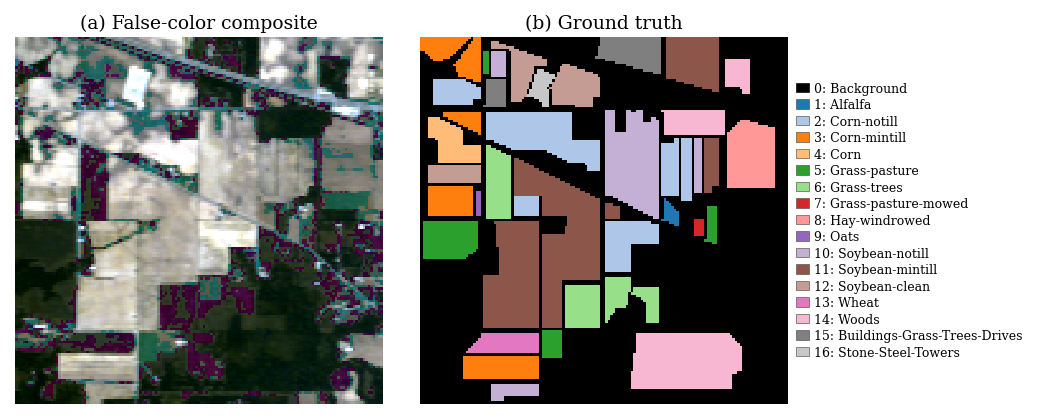


Creating band and spectral-variation figure...
Saved: figures/indian_pines_band_spectral_std.pdf
Saved: figures/indian_pines_band_spectral_std.png


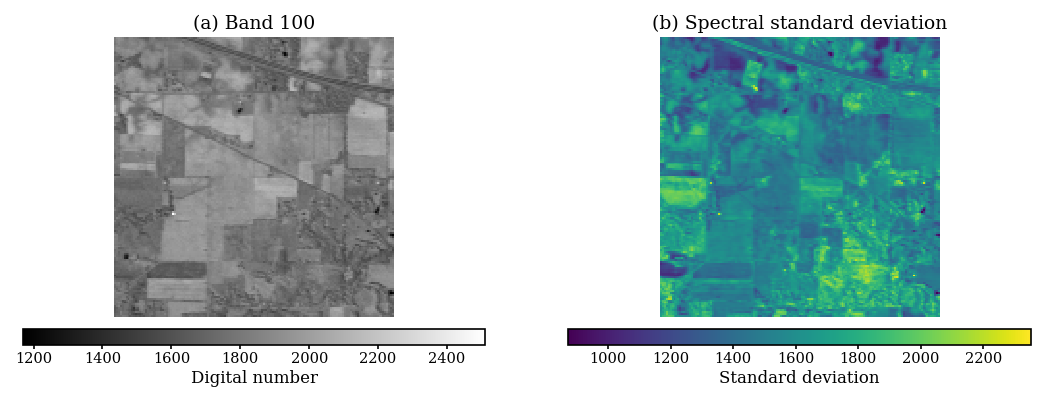


Plotting class distribution...


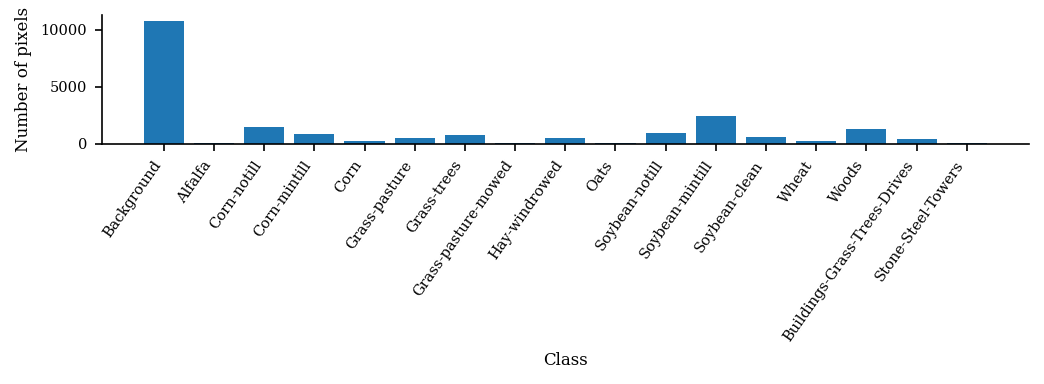


Plotting sample spectra...


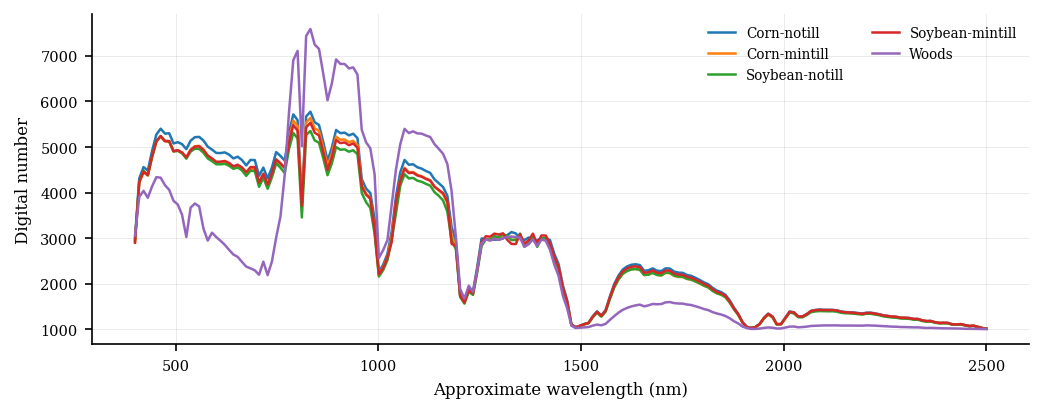

In [3]:
# Create visualizer instance
visualizer = IndianPinesVisualizer()

# Load the dataset
visualizer.load_data()

# print(f"DEBUG: Visualizer data shape after load: {visualizer.data.shape if visualizer.data is not None else 'None'}")
# print(f"DEBUG: Visualizer labels shape after load: {visualizer.labels.shape if visualizer.labels is not None else 'None'}")
# print(f"DEBUG: Visualizer data dtype after load: {visualizer.data.dtype if visualizer.data is not None else 'None'}")
# print(f"DEBUG: Visualizer labels dtype after load: {visualizer.labels.dtype if visualizer.labels is not None else 'None'}")

# Create all visualizations
visualizer.visualize_dataset()